In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from hmmlearn import hmm
import yfinance as yf
import math

In [35]:
def bs_d1d2(spot, strike, ivol, time_to_expiry, rf_rate, div_yield):
    d1 = (math.log(spot / strike) + (rf_rate - div_yield + 0.5 * ivol ** 2) * time_to_expiry) / (ivol * math.sqrt(time_to_expiry))
    d2 = d1 - ivol * math.sqrt(time_to_expiry)
    return d1, d2

def bs_price(spot, strike, ivol, time_to_expiry, rf_rate, div_yield, option_type):
    d1, d2 = bs_d1d2(spot, strike, ivol, time_to_expiry, rf_rate, div_yield)
    if option_type == 'call':
        price = spot * math.exp(-div_yield * time_to_expiry) * stats.norm.cdf(d1) - strike * math.exp(-rf_rate * time_to_expiry) * stats.norm.cdf(d2)
    elif option_type == 'put':
        price = strike * math.exp(-rf_rate * time_to_expiry) * stats.norm.cdf(-d2) - spot * math.exp(-div_yield * time_to_expiry) * stats.norm.cdf(-d1)
    return price

def bs_delta(spot, strike, ivol, time_to_expiry, rf_rate, div_yield, option_type):
    d1, _ = bs_d1d2(spot, strike, ivol, time_to_expiry, rf_rate, div_yield)
    if option_type == 'call':
        delta = math.exp(-div_yield * time_to_expiry) * stats.norm.cdf(d1)
    elif option_type == 'put':
        delta = math.exp(-div_yield * time_to_expiry) * (stats.norm.cdf(d1) - 1)
    return delta

def bs_gamma(spot, strike, ivol, time_to_expiry, rf_rate, div_yield):
    d1, _ = bs_d1d2(spot, strike, ivol, time_to_expiry, rf_rate, div_yield)
    gamma = math.exp(-div_yield * time_to_expiry) * stats.norm.pdf(d1) / (spot * ivol * math.sqrt(time_to_expiry))
    return gamma

def bs_vega(spot, strike, ivol, time_to_expiry, rf_rate, div_yield):
    d1, _ = bs_d1d2(spot, strike, ivol, time_to_expiry, rf_rate, div_yield)
    vega = spot * math.exp(-div_yield * time_to_expiry) * stats.norm.pdf(d1) * math.sqrt(time_to_expiry)
    return vega

def bs_theta(spot, strike, ivol, time_to_expiry, rf_rate, div_yield, option_type):
    d1, d2 = bs_d1d2(spot, strike, ivol, time_to_expiry, rf_rate, div_yield)
    if option_type == 'call':
        theta = - (spot * math.exp(-div_yield * time_to_expiry) * stats.norm.pdf(d1) * ivol) / (2 * math.sqrt(time_to_expiry)) + div_yield * spot * math.exp(-div_yield * time_to_expiry) * stats.norm.cdf(d1) - rf_rate * strike * math.exp(-rf_rate * time_to_expiry) * stats.norm.cdf(d2)
    elif option_type == 'put':
        theta = - (spot * math.exp(-div_yield * time_to_expiry) * stats.norm.pdf(d1) * ivol) / (2 * math.sqrt(time_to_expiry)) - div_yield * spot * math.exp(-div_yield * time_to_expiry) * stats.norm.cdf(-d1) + rf_rate * strike * math.exp(-rf_rate * time_to_expiry) * stats.norm.cdf(-d2)
    return theta

def bs_rho(spot, strike, ivol, time_to_expiry, rf_rate, div_yield, option_type):
    _, d2 = bs_d1d2(spot, strike, ivol, time_to_expiry, rf_rate, div_yield)
    if option_type == 'call':
        rho = strike * time_to_expiry * math.exp(-rf_rate * time_to_expiry) * stats.norm.cdf(d2)
    elif option_type == 'put':
        rho = -strike * time_to_expiry * math.exp(-rf_rate * time_to_expiry) * stats.norm.cdf(-d2)
    return rho

Mouvement Brownien Géométrique pour générer des chemins de prix 

Option Price: 7.36
Delta: 0.5096
Gamma: 0.0195
Vega: 39.0554
Theta: -3.3223
Rho: 43.6000


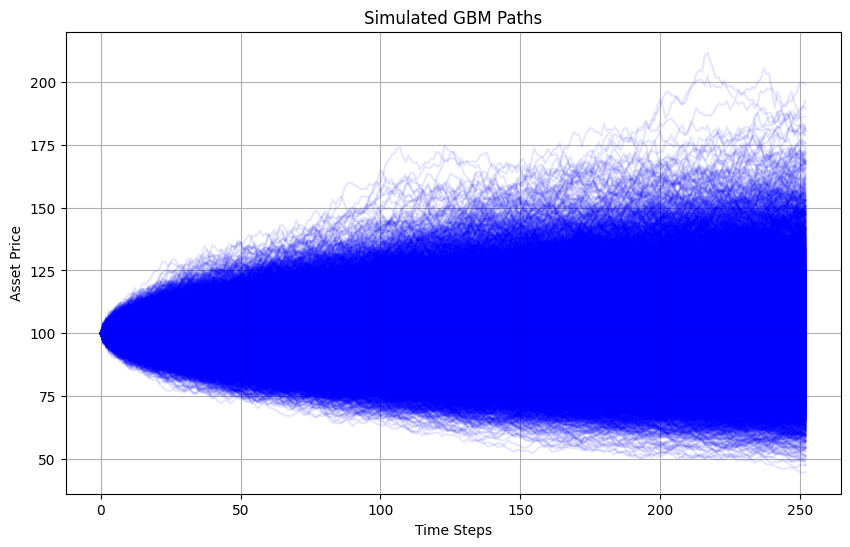

In [36]:
def simulate_gbm_paths(spot, drift, volatility, time_to_expiry, steps, num_paths):
    dt = time_to_expiry / steps
    paths = np.zeros((num_paths, steps + 1))
    paths[:, 0] = spot
    for t in range(1, steps + 1):
        z = np.random.standard_normal(num_paths)
        paths[:, t] = paths[:, t - 1] * np.exp((drift - 0.5 * volatility ** 2) * dt + volatility * np.sqrt(dt) * z)
    return paths

#Inputs
spot_price = 100
strike_price = 100
implied_volatility = 0.2
time_to_expiry = 1
risk_free_rate = 0.01
dividend_yield = 0.02
option_type = 'call'

#Calculate option price and Greeks
option_price = bs_price(spot_price, strike_price, implied_volatility, time_to_expiry, risk_free_rate, dividend_yield, option_type)
delta = bs_delta(spot_price, strike_price, implied_volatility, time_to_expiry, risk_free_rate, dividend_yield, option_type)
gamma = bs_gamma(spot_price, strike_price, implied_volatility, time_to_expiry, risk_free_rate, dividend_yield)
vega = bs_vega(spot_price, strike_price, implied_volatility, time_to_expiry, risk_free_rate, dividend_yield)
theta = bs_theta(spot_price, strike_price, implied_volatility, time_to_expiry, risk_free_rate, dividend_yield, option_type)
rho = bs_rho(spot_price, strike_price, implied_volatility, time_to_expiry, risk_free_rate, dividend_yield, option_type)
print(f"Option Price: {option_price:.2f}")
print(f"Delta: {delta:.4f}")
print(f"Gamma: {gamma:.4f}")
print(f"Vega: {vega:.4f}")
print(f"Theta: {theta:.4f}")
print(f"Rho: {rho:.4f}")
#Simulate GBM paths
num_paths = 10000
drift = risk_free_rate - dividend_yield
gbm_paths = simulate_gbm_paths(spot_price, drift, implied_volatility, time_to_expiry, 252, num_paths)
plt.figure(figsize=(10, 6))
plt.plot(gbm_paths.T, color='blue', alpha=0.1)
plt.title('Simulated GBM Paths')
plt.xlabel('Time Steps')
plt.ylabel('Asset Price')
plt.grid()
plt.show()

In [ ]:
data = yf.download("^GSPC", start="2020-01-01", end="2024-06-30")
prices = data["Close"]
returns = np.log(prices).diff().dropna()

[*********************100%***********************]  1 of 1 completed


In [39]:
def detect_regime(returns, n_regimes=2):
    X = returns.values.reshape(-1,1)
    model = hmm.GaussianHMM(
        n_components=n_regimes,
        covariance_type="full",
        n_iter=500,
        random_state=42
    )
    model.fit(X)
    regimes = model.predict(X)
    return regimes, model

regimes, model = detect_regime(returns)
returns = returns.copy()
returns.columns = ["ret"]
returns["regime"] = regimes



DETECTION DE REGIME

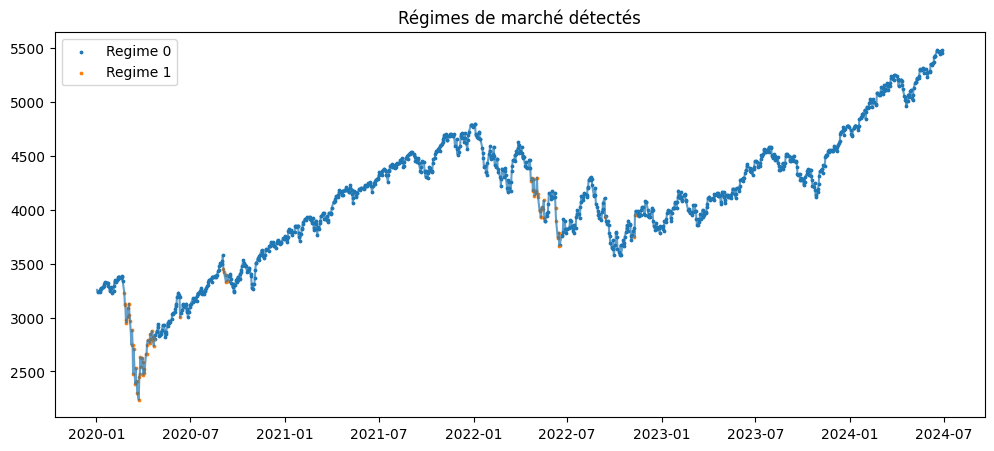

In [40]:
plt.figure(figsize=(12,5))
plt.plot(prices.index, prices, alpha=0.7)

for r in np.unique(regimes):
    mask = returns["regime"] == r
    plt.scatter(prices.index[1:][mask], prices.iloc[1:][mask], s=3, label=f"Regime {r}")

plt.legend()
plt.title("Régimes de marché détectés")
plt.show()


In [41]:
def hedge_ratio(regime):
    if regime == 0:
        return 0.5   # hedge partiel
    else:
        return 1.2   # hedge agressif

In [44]:
spot = prices.iloc[0]
strike = spot
vol = returns.std()*np.sqrt(252)
T = 1
r = 0.01
q = 0.0
option_type = 'put'

portfolio_pnl = []

for i in range(1, len(prices)):
    price, delta = bs_delta(
        spot=prices.iloc[i-1],
        strike=strike,
        ivol=vol,
        time_to_expiry=T,
        rf_rate=r,
        div_yield=q,
        option_type=option_type
    )

    hedge = hedge_ratio(returns["regime"].iloc[i]) * delta
    pnl = delta*(prices.iloc[i]-prices.iloc[i-1]) - hedge*(prices.iloc[i]-prices.iloc[i-1])
    portfolio_pnl.append(pnl)



/var/folders/dp/9gbs5ccj4p38dhz5lvdhvbnh0000gn/T/ipykernel_39362/1544751104.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  d1 = (math.log(spot / strike) + (rf_rate - div_yield + 0.5 * ivol ** 2) * time_to_expiry) / (ivol * math.sqrt(time_to_expiry))


IndexError: single positional indexer is out-of-bounds

In [ ]:
cum_pnl = np.cumsum(portfolio_pnl)

plt.figure(figsize=(10,4))
plt.plot(cum_pnl)
plt.title("PnL du hedging adaptatif par régime")
plt.grid()
plt.show()


ValueError: Found array with 0 sample(s) (shape=(0, 1)) while a minimum of 1 is required.